In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot  as plt
from sklearn.decomposition import NMF
from sklearn.datasets import fetch_olivetti_faces
from scipy.io import loadmat
from sklearn.model_selection import train_test_split


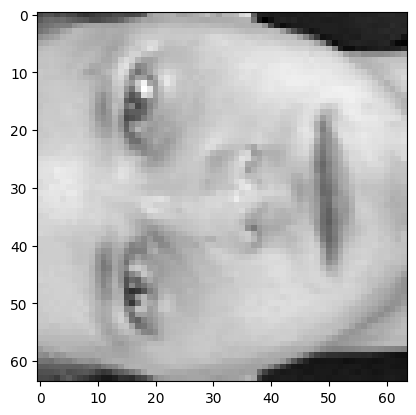

In [2]:
data = loadmat("olivettifaces.mat")
faces = data["faces"]  
X = faces.T  

plt.imshow(X[0].reshape(64, 64), cmap='gray')
plt.show()

In [3]:
y = np.repeat(np.arange(40), 10)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

print(y.shape)

(400,)


In [7]:
model = NMF(n_components=25, init='nndsvda', random_state=0, max_iter=500)
W_train = model.fit_transform(X_train)  
H = model.components_ 

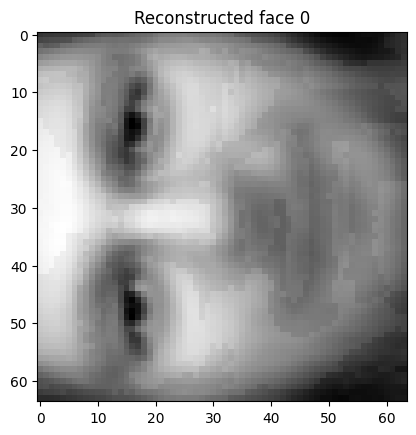

In [8]:
reconstruction = W_train[0] @ H
plt.imshow(reconstruction.reshape(64, 64), cmap='gray')
plt.title("Reconstructed face 0")
plt.show()

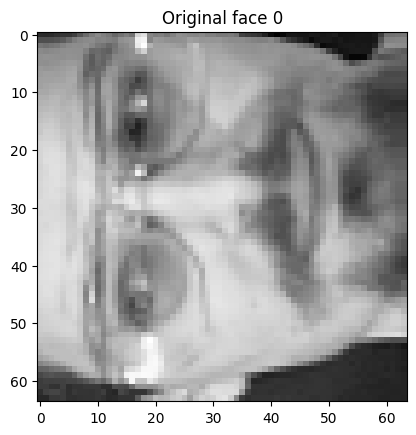

In [9]:
plt.imshow(X_train[0].reshape(64, 64), cmap='gray')
plt.title("Original face 0")
plt.show()

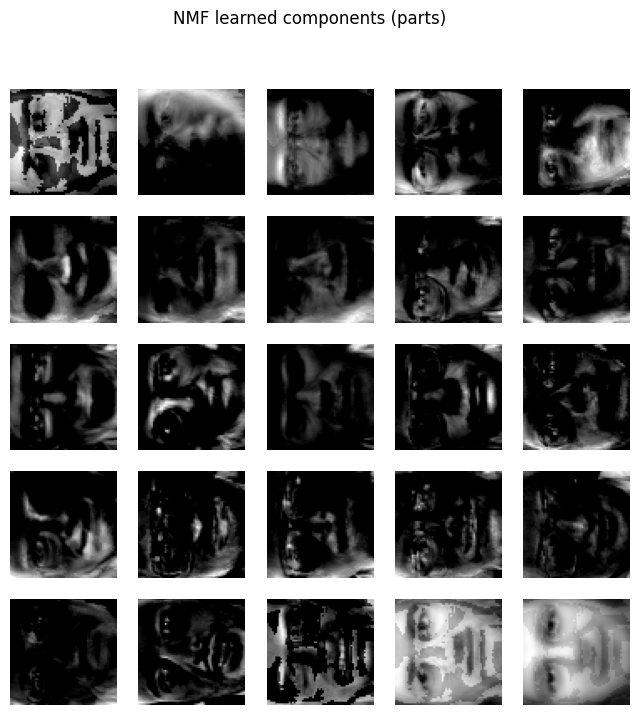

In [10]:
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(H[i].reshape(64, 64), cmap='gray')
    ax.axis('off')
plt.suptitle("NMF learned components (parts)")
plt.show()

In [12]:
X_train_lim = X_train[:100]  
print("Shape of 100 images train dataset: {}".format(X_train_lim.shape))  
  
X_train_lim = X_train_lim.reshape((100, 64*64))  
print("Shape of 100 images train dataset: {}".format(X_train_lim.shape))

Shape of 100 images train dataset: (100, 4096)
Shape of 100 images train dataset: (100, 4096)


In [13]:
model = NMF(n_components=25, random_state=42)  
features = model.fit_transform(X_train_lim)  
  
print("Transformed Data Shape: {}".format(features.shape))  
print("Model's Component Shape: {}".format(model.components_.shape))

Transformed Data Shape: (100, 25)
Model's Component Shape: (25, 4096)


In [ ]:
# Function produces 25 learned parts

# def show_as_image(sample):  
# 	plt.figure()  
# 	plt.imshow(sample, interpolation='nearest')  
# 	plt.colorbar()  
# 	plt.show() 
 
# for component in model.components_:  
# 	component = component.reshape(64, 64)  
# 	show_as_image(component)

In [ ]:
# cmap options
# 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'binary', 'spring', 'summer', 'autumn', 'winter', 'BrBG', 'RdBu', 'gist_rainbow', 'twilight'

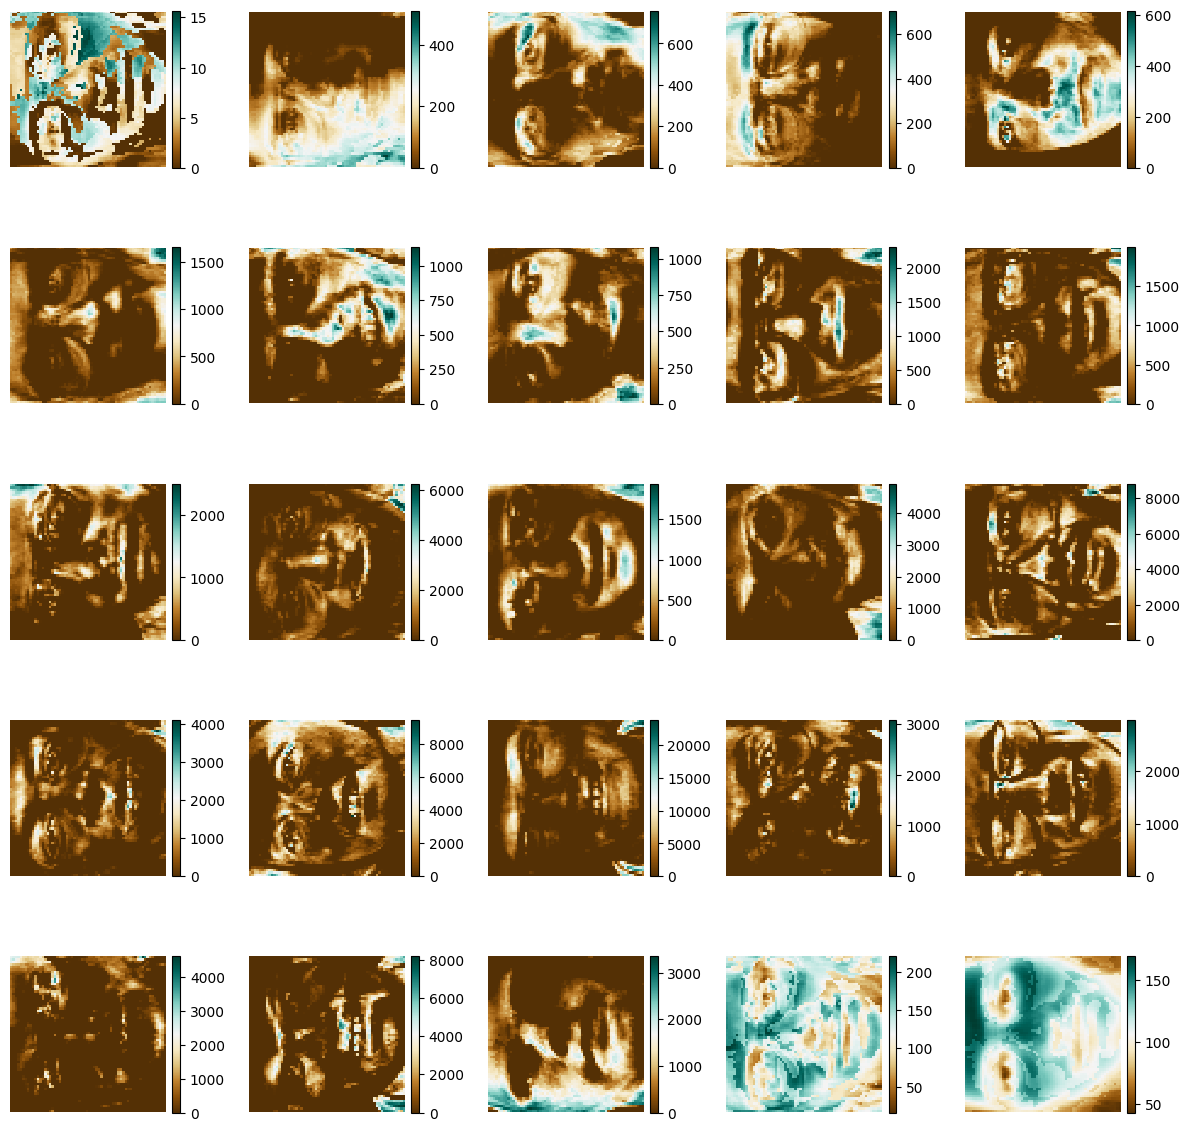

In [32]:
fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    component = model.components_[i].reshape(64, 64)
    im = ax.imshow(component, interpolation='nearest', cmap='BrBG')
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Each row of `model.components_` is a learned "part" — a 4096-length vector representing a 64×64 grayscale pattern. Reshaping each one back to (64, 64) lets us view it as an image.
</br></br>
Since NMF constrains all values to be non-negative, these components tend to correspond to interpretable, localized facial features (e.g. eyebrows, nose shapes, mouth regions) rather than whole faces or abstract patterns — unlike PCA, whose components mix positive and negative values and are harder to interpret visually.
</br></br>
The code above plots all 25 components in a 5×5 grid, using interpolation='nearest' to avoid smoothing/blurring the pixel values, with a colorbar on each subplot to show the intensity scale of that component.


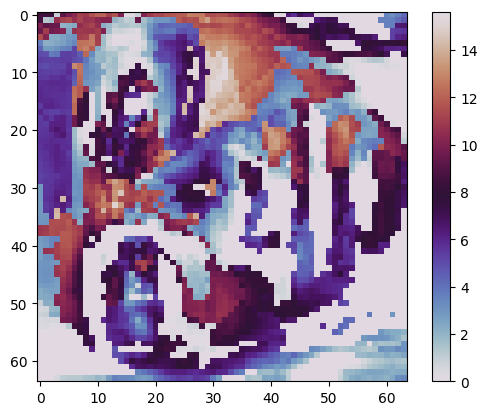

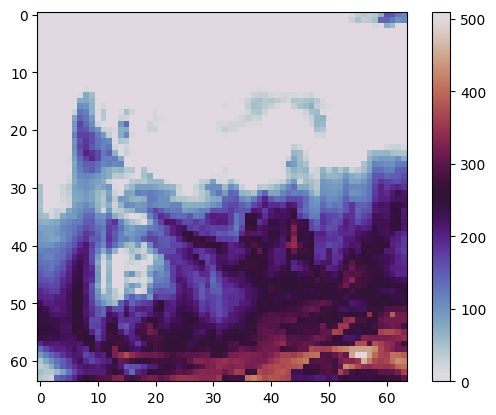

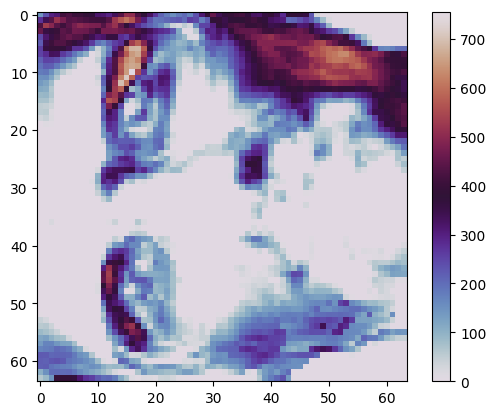

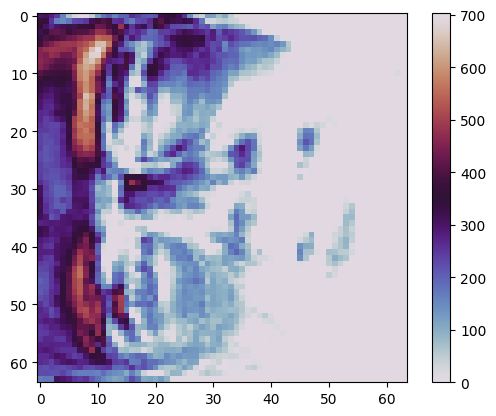

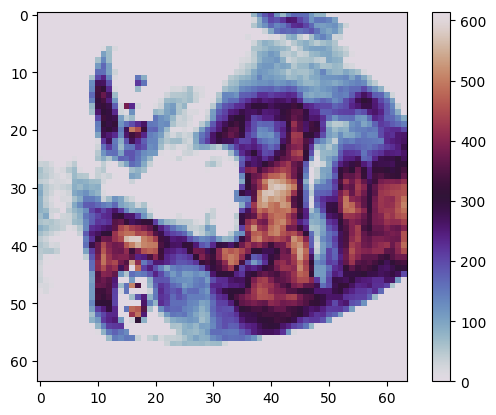

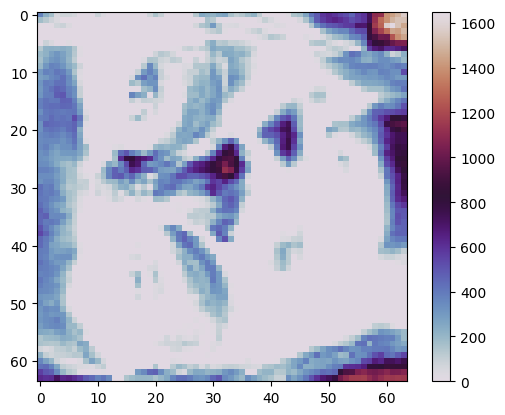

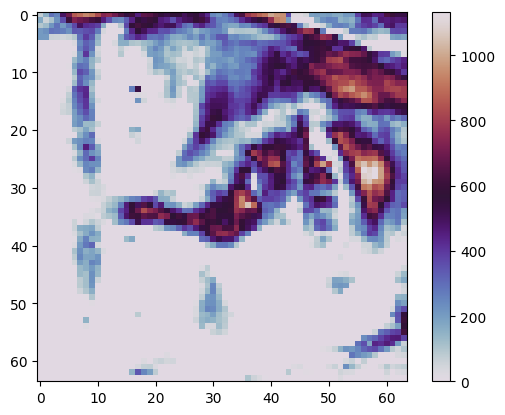

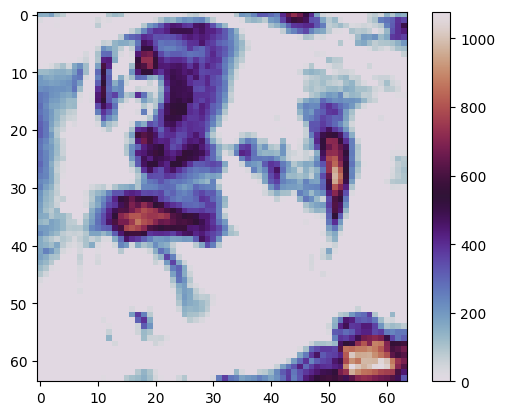

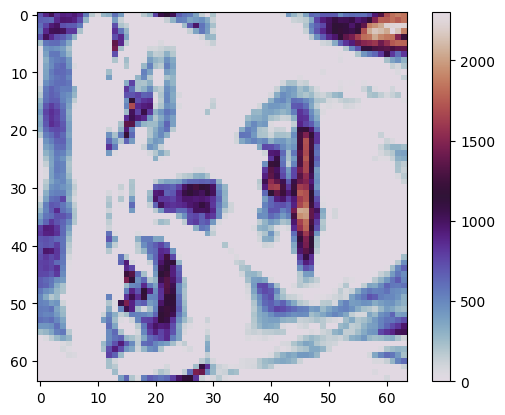

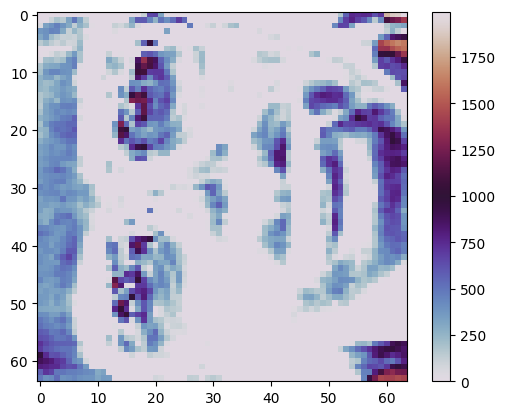

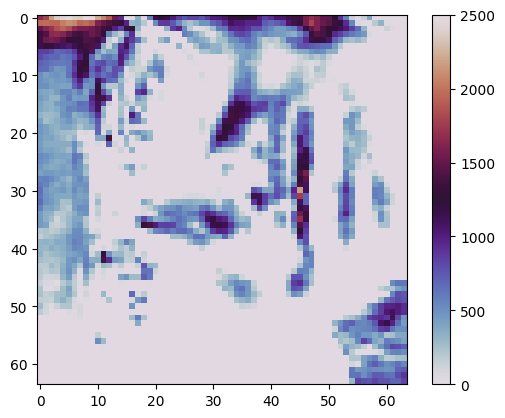

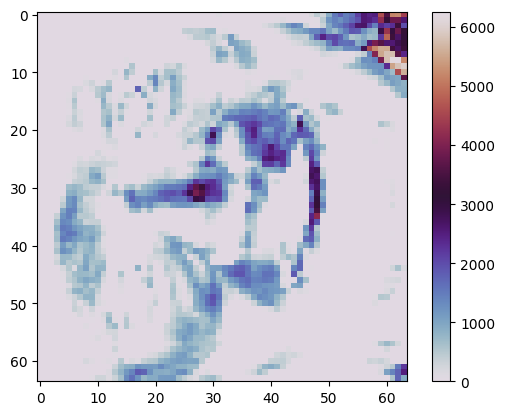

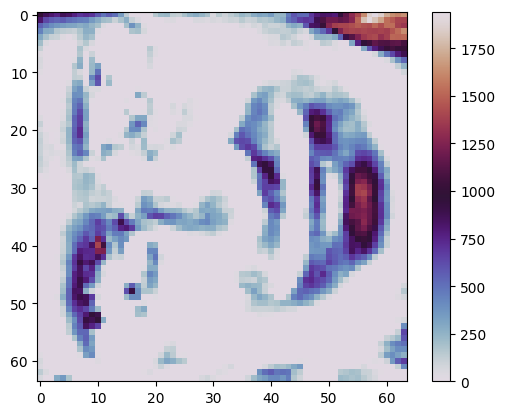

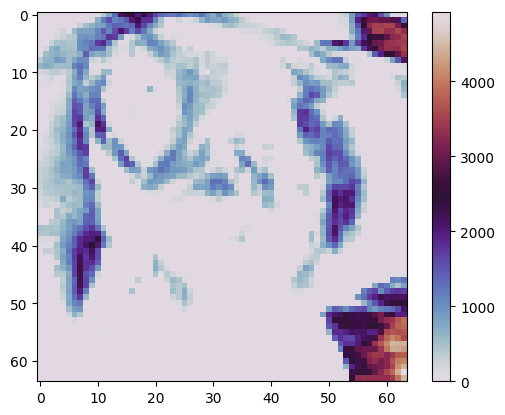

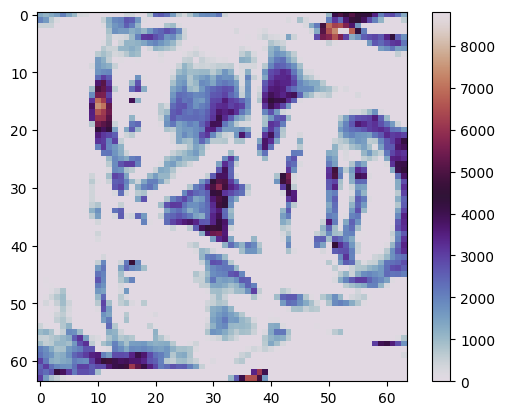

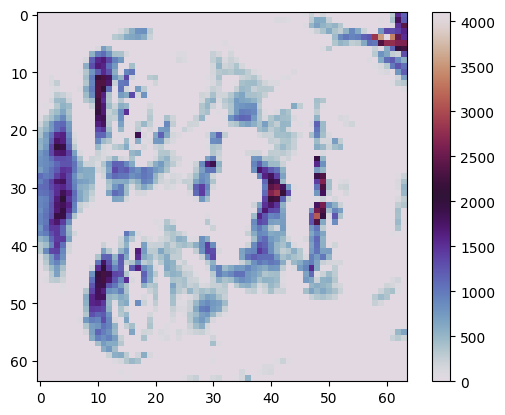

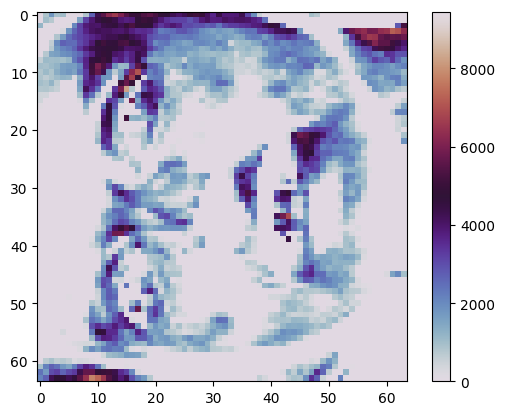

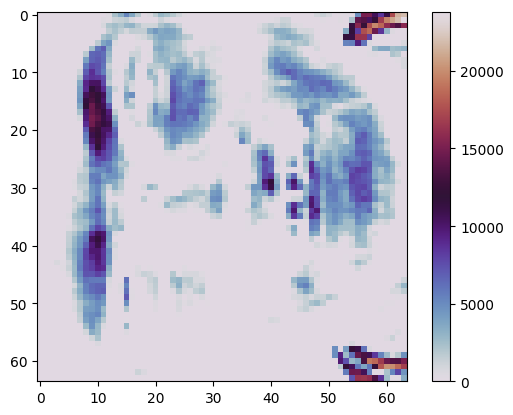

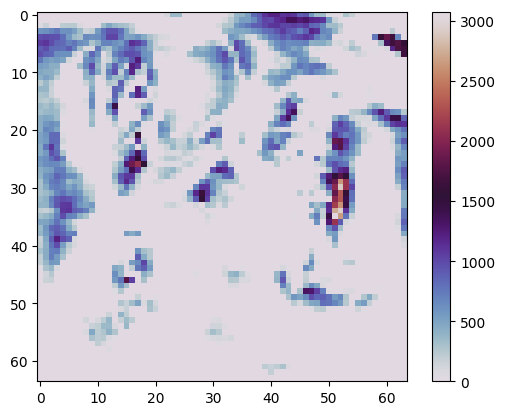

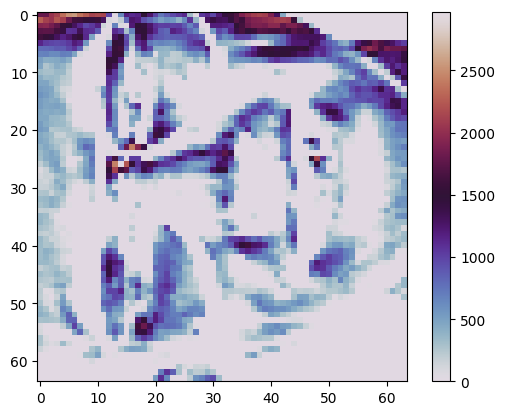

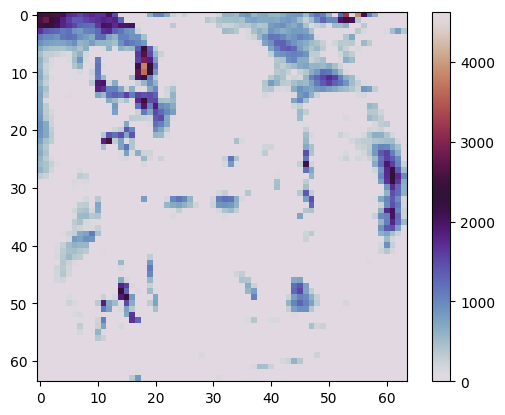

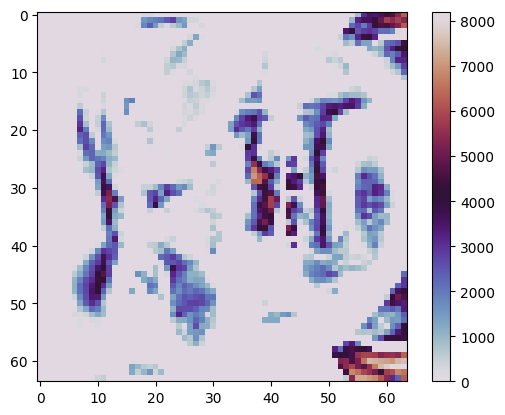

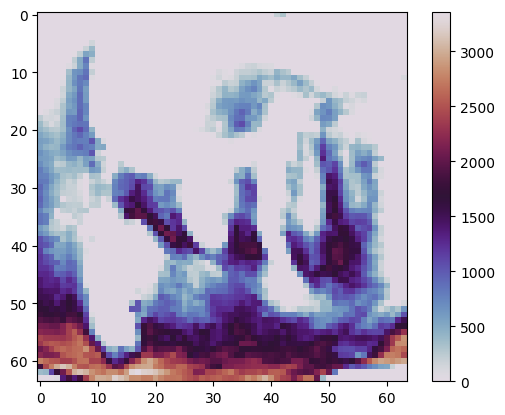

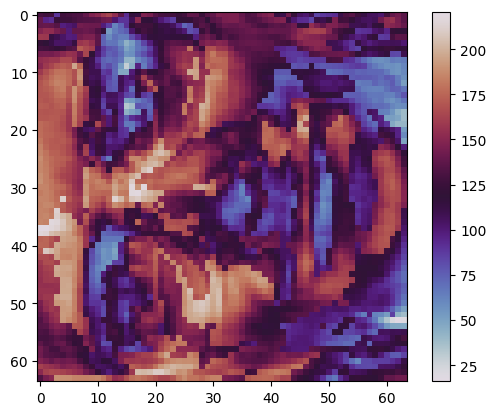

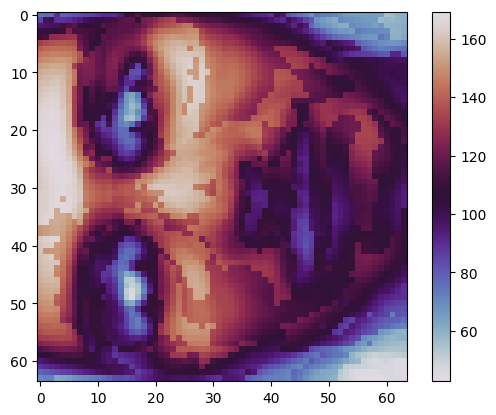

In [24]:
def show_as_image(sample):  
	plt.figure()  
	plt.imshow(sample, interpolation='nearest', cmap='twilight')  
	plt.colorbar()  
	plt.show() 
 
for component in model.components_:  
	component = component.reshape(64, 64)  
	show_as_image(component)